# Student Dropout and Academic Success Prediction


## Introduction
Student dropout is a significant challenge in higher education, impacting both institutional performance and long-term student outcomes. Early identification of at-risk students enables institutions to intervene before disengagement becomes irreversible. This project presents an end-to-end machine learning approach to predict student academic outcomes using academic, demographic, and financial features. The solution demonstrates a complete data science workflow from preprocessing to model evaluation and deployment readiness.

## Business Objective and Use Case
The objective of this project is to identify students at risk of dropping out at an early stage using data-driven insights. The model supports institutions in providing targeted academic assistance, financial aid, and counseling interventions. From a business perspective, the solution can be integrated into institutional decision-support systems to prioritize resources and improve retention strategies. This enables proactive intervention, improved student success rates, and more efficient use of institutional resources.


In [369]:
# Core libraries
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [370]:
# Preprocessing & ML
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             cohen_kappa_score)


In [371]:
# Model persistence
import joblib


## Data Preprocessing Strategy

The preprocessing strategy is designed to ensure consistency between training and deployment while minimizing the risk of data leakage. All transformations are applied only after the train–test split and are managed through structured preprocessing workflows.

This phase focuses on:
- Ensuring consistent and standardized column naming
- Verifying data types across all features
- Detecting and assessing missing values

These steps provide an initial assessment of data quality and guide preprocessing and feature-handling decisions.


In [372]:
# Display all columns in DataFrame outputs to avoid column truncation during inspection
pd.set_option('display.max_columns', None)

# Apply a clean white grid style to seaborn plots for better readability and consistency
sns.set_style("whitegrid")


## Dataset Loading and Initial Inspection

The dataset is loaded into a pandas DataFrame to examine its structure, dimensionality, and initial records. This step ensures that the data has been read correctly before further analysis and preprocessing.


In [373]:
# Load the dataset from a CSV file using semicolon as the delimiter
df = pd.read_csv("data.csv", sep=';')

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Dataset Description
The dataset contains student-level information collected at enrollment and during the first two semesters. It includes demographic attributes, academic performance indicators, and financial and socioeconomic factors.


In [374]:
# Remove leading and trailing whitespace from column names for consistency and easier reference
df.columns = df.columns.str.strip()
df.columns


Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nationality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [375]:
# Display a concise summary of the DataFrame, including column names, data types,
# non-null counts, and memory usage to assess overall data structure and quality
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nationality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [376]:
# Calculate the number of missing values for each feature
missing = df.isnull().sum()

# Check whether any missing values exist in the dataset
if missing.sum() == 0:
    print("No missing values detected.")
else:
    # Visualize missing values per feature using a bar plot
    plt.figure(figsize=(12, 4))
    sns.barplot(x=missing.index, y=missing.values)
    plt.xticks(rotation=90)
    plt.title("Missing Values per Feature")
    plt.show()


No missing values detected.


## Summary Statistics

Descriptive statistics are used to examine feature distributions, value ranges, and variability within the dataset. Both numerical and categorical features are analyzed to gain a clear understanding of overall data characteristics and patterns.


In [377]:
df.describe(include='all').T.round(2)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous qualification (grade),4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nationality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mother's qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Father's qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


The target variable consists of three classes.


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to gain initial insights into the dataset and uncover patterns that may influence student outcomes. The analysis focuses on:
- Examining the distribution of the target variable
- Identifying the presence of class imbalance
- Exploring relationships among academic, demographic, and financial features
- Detecting trends relevant to student performance and retention

### Target Variable Distribution
Analyzing the target variable distribution helps assess class imbalance within the dataset. Since accurately identifying at-risk (Dropout) students is a key objective, imbalance-aware evaluation metrics are applied during model assessment.


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
Name: count, dtype: float64


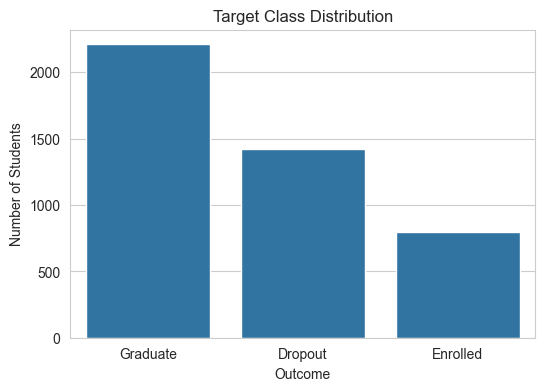

In [378]:
target_counts = df['Target'].value_counts()
print(target_counts)
print()
print(target_counts / target_counts.sum())

plt.figure(figsize=(6,4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title("Target Class Distribution")
plt.ylabel("Number of Students")
plt.xlabel("Outcome")
plt.show()


### Numerical Feature Distributions

Histograms of numerical features are used to examine data spread, skewness, and the presence of potential outliers. Understanding these distributions helps guide feature engineering decisions and supports appropriate model selection.


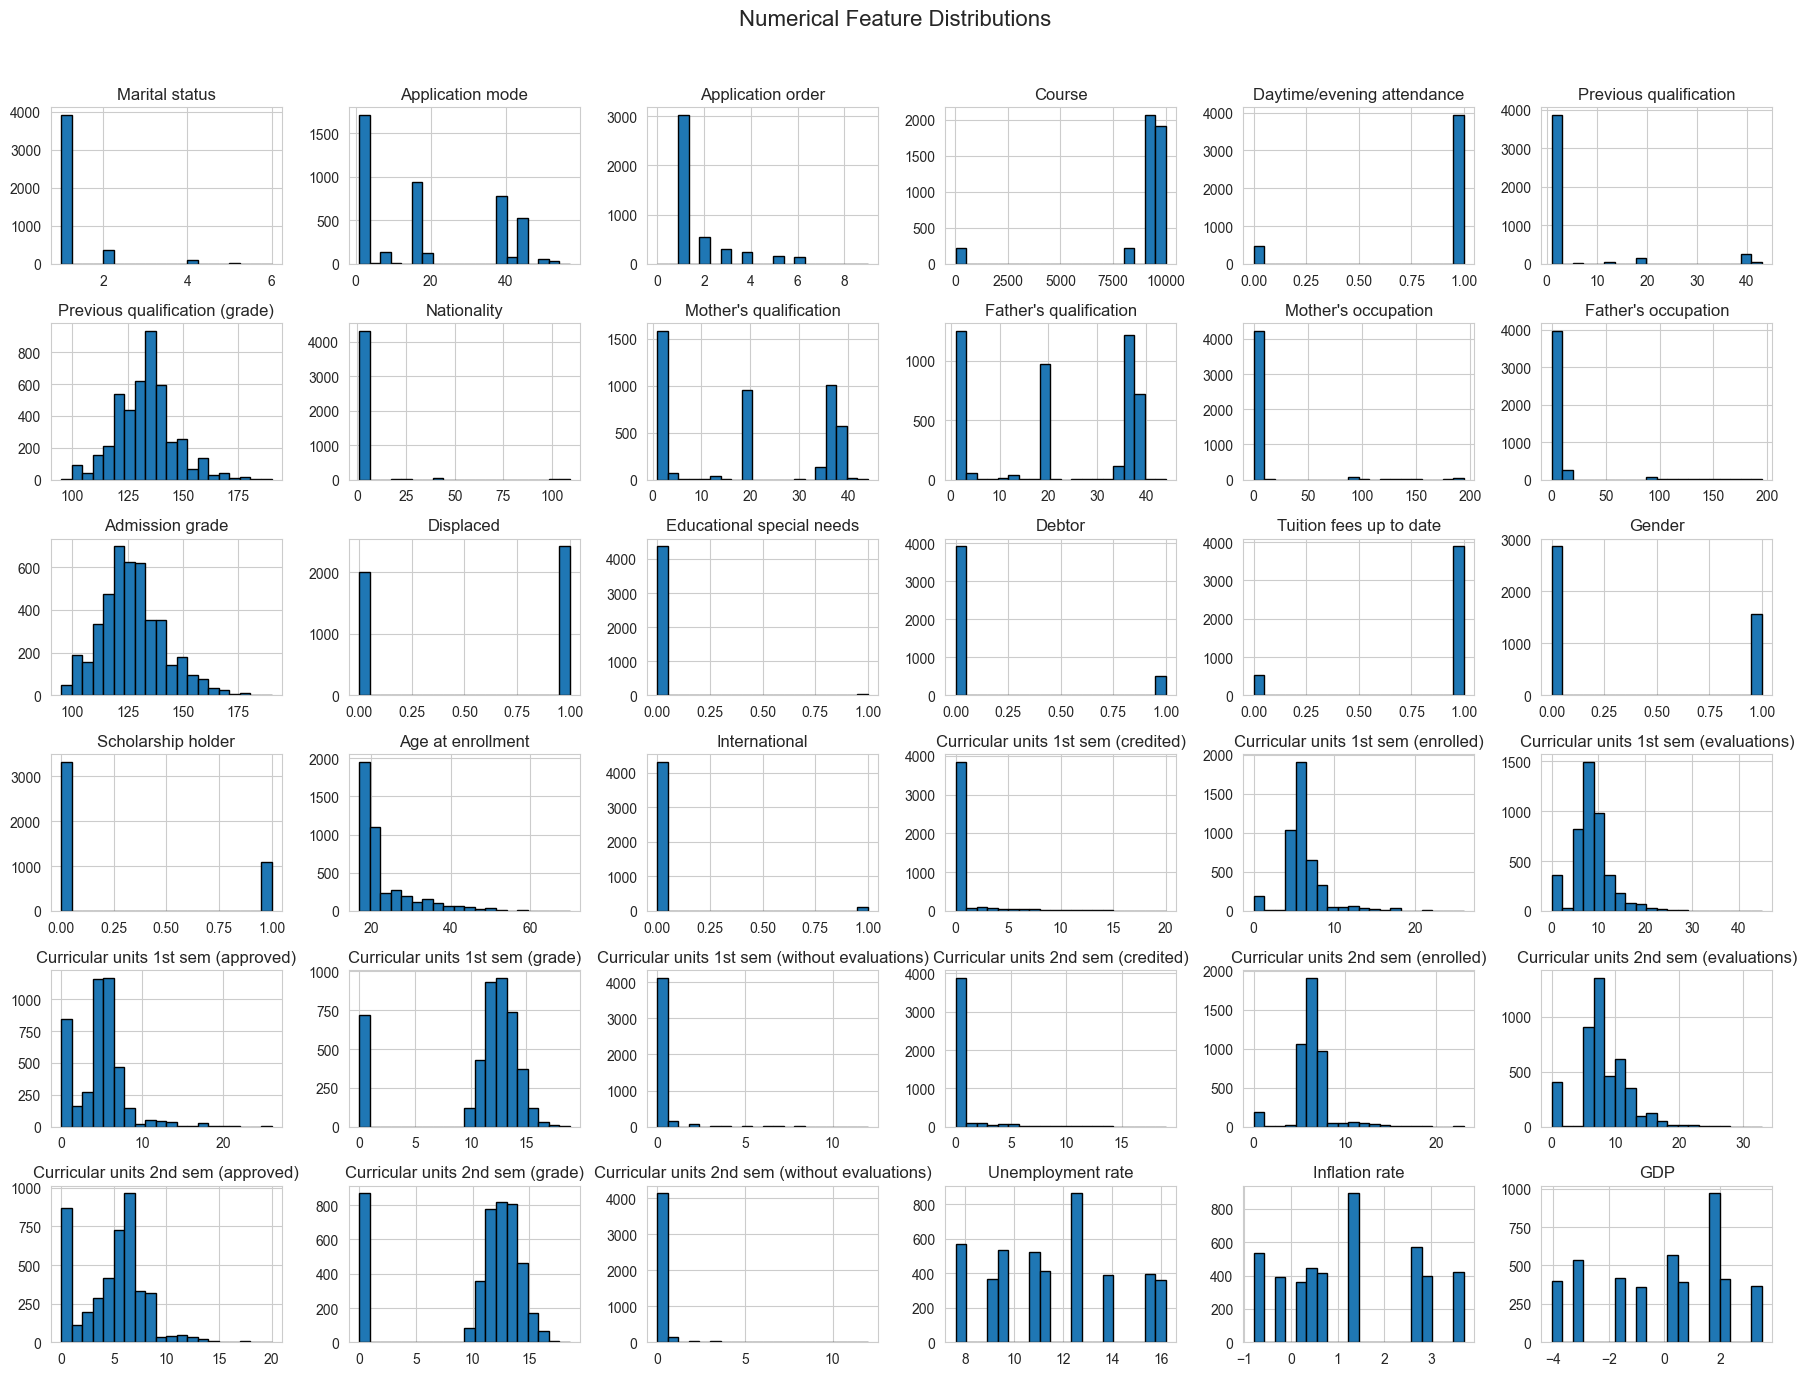

In [379]:
df.select_dtypes(include=['int64','float64']).hist(
    figsize=(18, 14), bins=20, edgecolor="black"
)
plt.suptitle("Numerical Feature Distributions", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Academic Performance and Student Outcomes

Academic engagement indicators, including approved curricular units and semester grades, are analyzed in relation to student outcomes. Boxplots are used to highlight performance differences between students who drop out and those who continue or graduate.


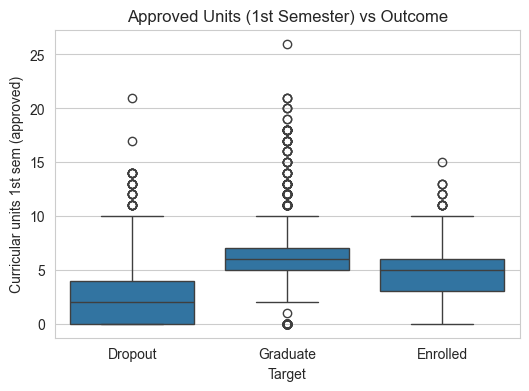

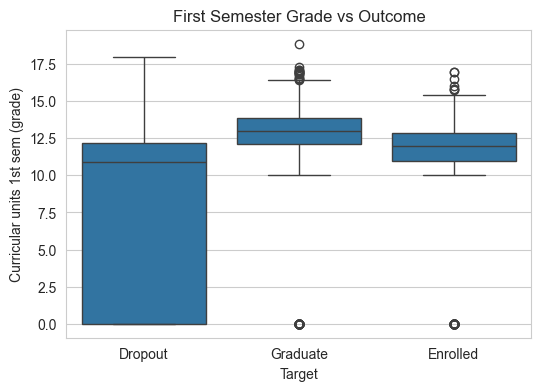

In [380]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Target', y='Curricular units 1st sem (approved)', data=df)
plt.title("Approved Units (1st Semester) vs Outcome")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Target', y='Curricular units 1st sem (grade)', data=df)
plt.title("First Semester Grade vs Outcome")
plt.show()


### Demographic and Financial Factors

Demographic characteristics and financial status are examined to assess their impact on student retention. Special emphasis is placed on tuition fee status as a potential indicator of dropout risk.


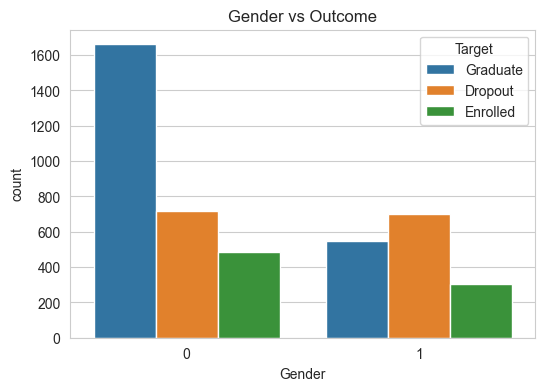

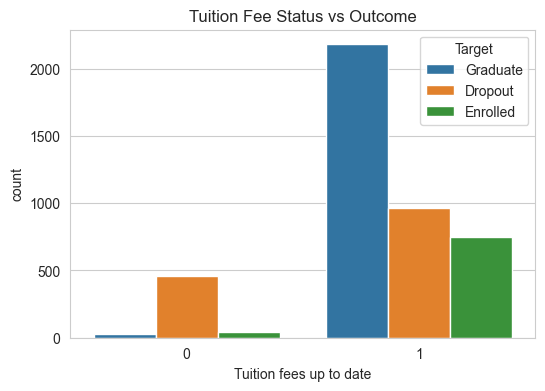

In [381]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Target', data=df)
plt.title("Gender vs Outcome")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Tuition fees up to date', hue='Target', data=df)
plt.title("Tuition Fee Status vs Outcome")
plt.show()


### Correlation Analysis

Correlation analysis of numerical features is conducted to identify linear relationships and potential multicollinearity, supporting informed feature selection and model choice.


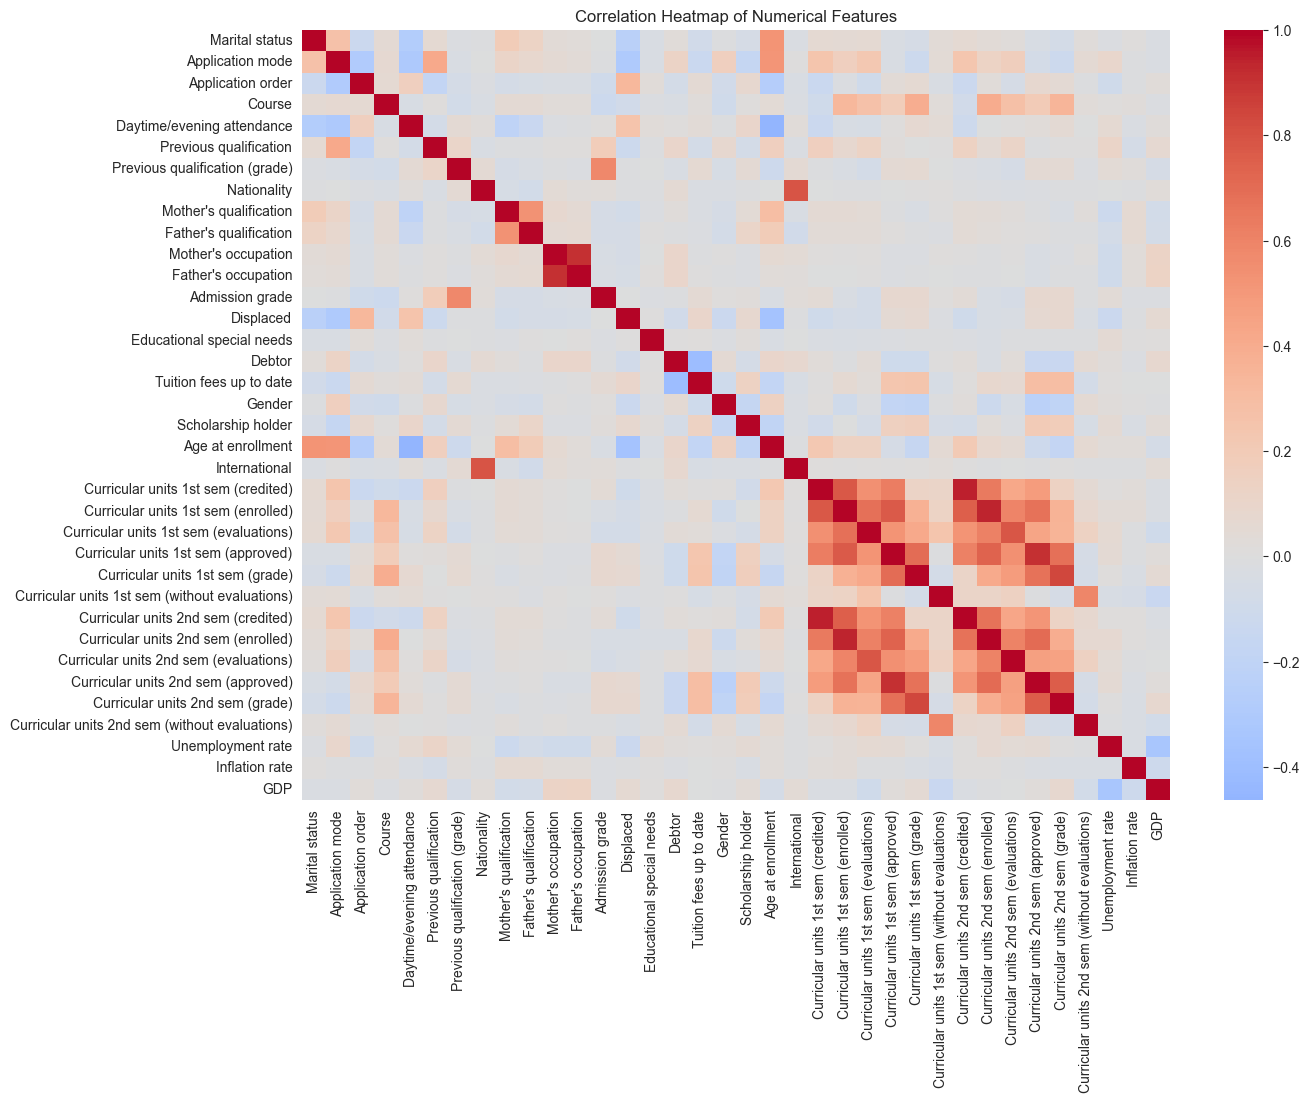

In [382]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(num_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


## Key Insights from EDA

- Academic performance indicators show a strong ability to differentiate student outcomes.
- Financial stability, particularly tuition fee status, exhibits a clear association with dropout risk.
- Demographic variables demonstrate a comparatively weaker influence on student outcomes.
- The dataset exhibits class imbalance, highlighting the importance of using appropriate evaluation metrics.


## Feature Selection and Engineering Rationale

Not all attributes in the original dataset are equally informative or practical for predictive modeling. Feature selection was applied to reduce model complexity and minimize overfitting, thereby improving generalization on unseen data. Academic performance indicators—such as approved units, grades, and enrollment behavior—were prioritized due to their strong predictive power. Demographic and macroeconomic variables were retained selectively, as they may be static or unavailable at prediction time. Features that could introduce data leakage were excluded. This approach balances predictive accuracy with real-world deployability.


In [383]:
X = df.drop(columns=['Target'])
y = df['Target']


In [384]:
# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Target Label Mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))


Target Label Mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


In [385]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Categorical Features:", len(categorical_cols))
print("Numerical Features:", len(numerical_cols))


Categorical Features: 0
Numerical Features: 36


In [386]:
# Preprocessing pipelines
numeric_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


In [387]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])


## Train-Test Split

The dataset is partitioned into training and testing sets using stratified sampling to preserve the original class distribution. This approach ensures reliable and unbiased evaluation of model performance on unseen data.


In [388]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Fit and transform training data, transform test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)


Train shape: (3539, 36)
Test shape: (885, 36)


## Model Development and Selection

Multiple supervised learning models are evaluated to balance interpretability and predictive performance:
- Logistic Regression as a linear baseline model
- Decision Tree for rule-based interpretability
- Random Forest for ensemble-based robustness
- XGBoost for gradient-boosted performance


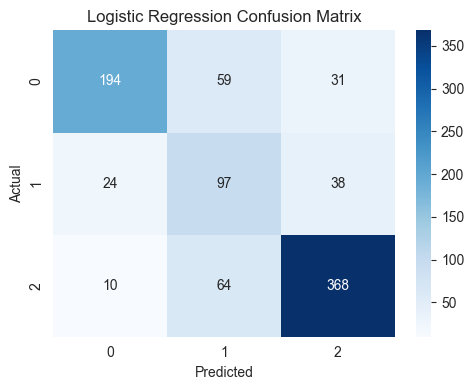

              precision    recall  f1-score   support

           0       0.85      0.68      0.76       284
           1       0.44      0.61      0.51       159
           2       0.84      0.83      0.84       442

    accuracy                           0.74       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.77      0.74      0.75       885



In [389]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
log_reg.fit(X_train_processed, y_train)
log_metrics, log_preds = evaluate_model(log_reg, X_test_processed, y_test)
plot_confusion(y_test, log_preds, "Logistic Regression Confusion Matrix")
print(classification_report(y_test, log_preds))


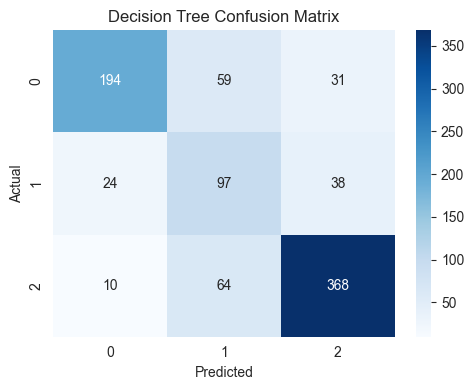

              precision    recall  f1-score   support

           0       0.85      0.68      0.76       284
           1       0.44      0.61      0.51       159
           2       0.84      0.83      0.84       442

    accuracy                           0.74       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.77      0.74      0.75       885



In [390]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=10, min_samples_split=10,
                            class_weight='balanced', random_state=42)
dt.fit(X_train_processed, y_train)
dt_metrics, dt_preds = evaluate_model(dt, X_test_processed, y_test)
plot_confusion(y_test, dt_preds, "Decision Tree Confusion Matrix")
print(classification_report(y_test, dt_preds))


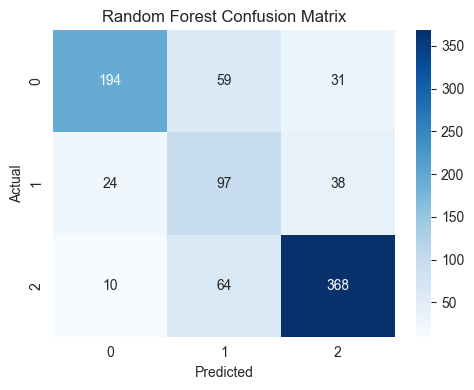

              precision    recall  f1-score   support

           0       0.85      0.68      0.76       284
           1       0.44      0.61      0.51       159
           2       0.84      0.83      0.84       442

    accuracy                           0.74       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.77      0.74      0.75       885



In [391]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=5,
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_processed, y_train)
rf_metrics, rf_preds = evaluate_model(rf, X_test_processed, y_test)
plot_confusion(y_test, rf_preds, "Random Forest Confusion Matrix")
print(classification_report(y_test, rf_preds))


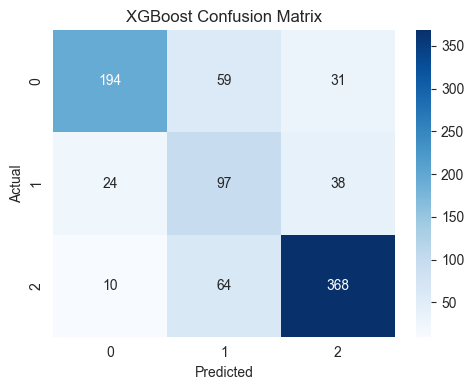

              precision    recall  f1-score   support

           0       0.85      0.68      0.76       284
           1       0.44      0.61      0.51       159
           2       0.84      0.83      0.84       442

    accuracy                           0.74       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.77      0.74      0.75       885



In [392]:
# XGBoost
xgb = XGBClassifier(objective='multi:softmax', num_class=3, n_estimators=300,
                    learning_rate=0.1, max_depth=6, subsample=0.8, colsample_bytree=0.8,
                    eval_metric='mlogloss', random_state=42)

xgb.fit(X_train_processed, y_train)
xgb_metrics, xgb_preds = evaluate_model(xgb, X_test_processed, y_test)
plot_confusion(y_test, xgb_preds, "XGBoost Confusion Matrix")
print(classification_report(y_test, xgb_preds))


## Hyperparameter Tuning

RandomizedSearchCV is used to optimize the Random Forest model by tuning key hyperparameters. Macro-averaged F1-score is selected as the optimization metric to account for class imbalance.

In [393]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_processed, y_train)


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,20
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## Final Model Selection

Based on comparative evaluation and hyperparameter tuning results, the tuned Random Forest model is selected as the final model for evaluation and deployment due to its strong predictive performance and robustness to class imbalance.


In [394]:
# Assign the tuned Random Forest model as the final model
best_model = random_search.best_estimator_


## Model Performance Comparison

Model performance is compared using macro-averaged evaluation metrics to ensure a balanced and fair assessment across all student outcome classes.


In [395]:
results = pd.DataFrame.from_dict({
    "Logistic Regression": log_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics,
    "XGBoost": xgb_metrics
}, orient='index')

results


,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Cohen Kappa
Logistic Regression,0.744633,0.70858,0.711297,0.70858,0.702334,0.592099
Decision Tree,0.744633,0.70858,0.711297,0.70858,0.702334,0.592099
Random Forest,0.744633,0.70858,0.711297,0.70858,0.702334,0.592099
XGBoost,0.744633,0.70858,0.711297,0.70858,0.702334,0.592099


In [396]:
# Save comparison metrics
os.makedirs("reports", exist_ok=True)
results.to_csv("reports/model_comparison_metrics.csv", index=False)


## Model Evaluation and Error Analysis

Model evaluation emphasizes metrics appropriate for imbalanced multiclass classification. Confusion matrices are used to gain deeper insight into prediction errors and misclassification patterns across student outcome classes.


In [397]:
def evaluate_model(model, X_test, y_test):
    y_pred = best_model.predict(X_test_processed)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(y_test, y_pred, average='macro'),
        "Macro Recall": recall_score(y_test, y_pred, average='macro'),
        "Macro F1": f1_score(y_test, y_pred, average='macro'),
        "Cohen Kappa": cohen_kappa_score(y_test, y_pred)
    }
    return metrics, y_pred

In [398]:
def plot_confusion(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


### Error Analysis and Interpretation

The confusion matrix reveals how model performance varies across outcome categories. Most misclassifications occur between *Enrolled* and *Dropout*, which is expected due to overlapping academic behaviors during early semesters. The model performs better in identifying *Graduate* students, who typically exhibit consistently higher grades and approval counts.

From an institutional perspective, misclassifying at-risk students as enrolled is more critical than the reverse. Therefore, recall for the *Dropout* class is treated as a key metric. Future improvements may include class weighting or threshold tuning to further reduce false negatives for potential dropouts.


In [399]:
# Save tuned model and preprocessing objects
os.makedirs("models", exist_ok=True)
joblib.dump(best_rf, "models/rf_model_tuned.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")


['models/label_encoder.pkl']

## Feature Importance Analysis

Feature importance scores derived from the Random Forest model are used to identify the most influential predictors contributing to student dropout risk.


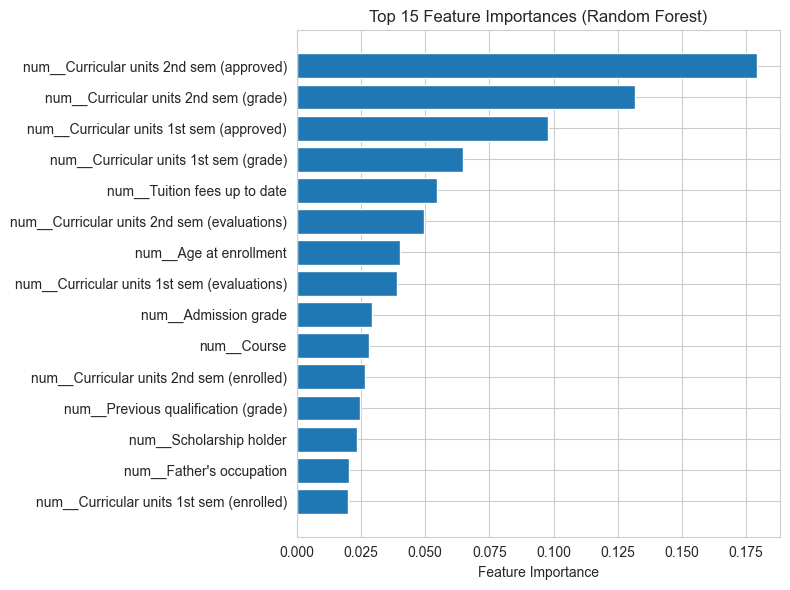

In [400]:
feature_names = preprocessor.get_feature_names_out()
importances = best_model.feature_importances_

# Safety check
assert len(feature_names) == len(importances), "Feature name and importance length mismatch"

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

# Select top 15 features
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Key Findings

- Academic engagement indicators are the most influential predictors of student outcomes.
- Financial factors, particularly tuition fee status, show a strong association with dropout risk.
- Ensemble-based models outperform linear baseline models across evaluation metrics.
- The tuned Random Forest model achieves the best balance between predictive performance and interpretability.


## Limitations and Future Scope

- Model performance is dependent on the quality and representativeness of historical data.
- The inclusion of behavioral and attendance-related features could further improve prediction accuracy.
- Periodic model retraining is recommended to maintain performance as student patterns evolve.


## Deployment Readiness

The trained model, preprocessing pipeline, and label encoder are saved as deployable artifacts. A Flask-based API is implemented to demonstrate real-time inference capability, supporting practical integration into institutional decision-support systems.


## Conclusion

This project presents a complete, production-oriented machine learning pipeline for predicting student dropout risk. By combining robust preprocessing, imbalance-aware evaluation, and interpretable modeling, the solution delivers actionable insights that support early intervention strategies in educational institutions.
